In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "functions").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "functions").exists() and (parent / "data").exists():
            REPO_ROOT = parent
            break
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

# Load cgm data
data = pd.read_csv(os.path.join("data", 'ai_readi.csv'))

In [3]:
# Counts (after interpolation processing)
gl_data = data.groupby('id').agg({'gl': list, 'time': list}).reset_index()
print("Number of measurements per subject:\n", gl_data['gl'].apply(len).describe())
print("\nOverall mean glucose level per subject:\n", gl_data['gl'].apply(np.mean).describe())

Number of measurements per subject:
 count    1013.000000
mean     2785.007897
std       188.323076
min      1439.000000
25%      2829.000000
50%      2856.000000
75%      2856.000000
max      3096.000000
Name: gl, dtype: float64

Overall mean glucose level per subject:
 count    1013.000000
mean      136.205797
std        30.613768
min        86.179094
25%       115.345588
50%       127.899860
75%       147.892857
max       312.933648
Name: gl, dtype: float64


# 2-hours window feature extraction

In [4]:
metadata = pd.read_csv(os.path.join("data", 'ai_readi_metadata_cleaned.csv'))

# id matching for gl_data
gl_data = gl_data[gl_data['id'].isin(metadata['id'])]
gl_data.shape

(968, 3)

In [ ]:
from data.window_processing import window_process

# Process the data (about 2 min with 10 cores)
print("\nProcessing AI-READY dataset...")
features_aiready = window_process(gl_data, n_jobs=10, window_size=120, overlap=0.75)
features_aiready.head()


Processing AI-READY dataset...
Processing 968 patients in parallel...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    3.3s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    4.3s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    5.4s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    5.8s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:    7.8s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    9.1s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:   10.5s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:   12.0s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:   13.8s
[Parallel(n_jobs=10)]: Done 108 tasks      | elapsed:   15.4s
[Parallel(n_jobs=10)]: Done 125 tasks      | elapsed:   17.5s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:   19.5s
[Parallel(n_jobs=10)]: Done 161 tasks      | elapsed:   21.7s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:   24.0s
[Parallel(n_jobs=10)]: Done 201 tasks      | elapsed:  

Total processing time: 110.90 seconds
Total windows extracted: 444063
Mean number of windows per patient: 458.74


,start_time,end_time,mean_glucose,cv_glucose,mad_consecutive,n_points,id
0,2023-07-27 23:51:43,2023-07-28 01:46:43,112.666667,0.090576,4.739130,24,1001
1,2023-07-28 00:21:43,2023-07-28 02:16:43,105.083333,0.126752,5.869565,24,1001
2,2023-07-28 00:51:43,2023-07-28 02:46:43,100.958333,0.116866,6.260870,24,1001
3,2023-07-28 01:21:43,2023-07-28 03:16:43,96.041667,0.097835,7.173913,24,1001
4,2023-07-28 01:51:43,2023-07-28 03:46:43,108.708333,0.232405,7.913043,24,1001


In [6]:
features_aiready = features_aiready.rename(columns={'mean_glucose': 'Mean', 'cv_glucose': 'CV', 'mad_consecutive': 'MAD'})
features_aiready.head()

,start_time,end_time,Mean,CV,MAD,n_points,id
0,2023-07-27 23:51:43,2023-07-28 01:46:43,112.666667,0.090576,4.739130,24,1001
1,2023-07-28 00:21:43,2023-07-28 02:16:43,105.083333,0.126752,5.869565,24,1001
2,2023-07-28 00:51:43,2023-07-28 02:46:43,100.958333,0.116866,6.260870,24,1001
3,2023-07-28 01:21:43,2023-07-28 03:16:43,96.041667,0.097835,7.173913,24,1001
4,2023-07-28 01:51:43,2023-07-28 03:46:43,108.708333,0.232405,7.913043,24,1001


In [7]:
# Save the processed data
features_aiready.to_csv("./data/aireadi_window120.csv", index=False)

#### Auxiliary exploratory analysis

In [8]:
from data.window_processing import prepare_frechet_data

features_aiready = pd.read_csv('data/aireadi_window120.csv')
feature_names = ['Mean', 'CV', 'MAD']

# Processing for frechet regression with selected features
aiready_processed = prepare_frechet_data(features_aiready, feature_names=feature_names)

Using R installation at: C:\Program Files\R\R-4.4.1
Processed 968 patients with sufficient data
Average windows per patient: 458.74
Calculating latent correlations... Done!


In [9]:
aiready_latentcor = np.array(aiready_processed['data']['latentcor'].tolist(), dtype=float)

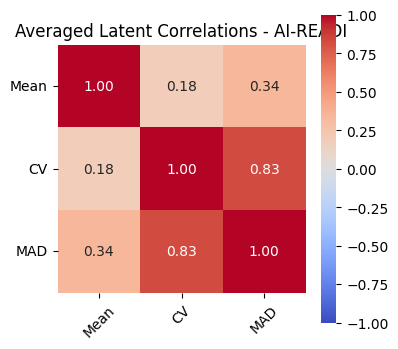

In [10]:
plt.figure(figsize=(4, 4))
sns.heatmap(aiready_latentcor.mean(0), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=feature_names, yticklabels=feature_names, square=True)
plt.title("Averaged Latent Correlations - AI-READI")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

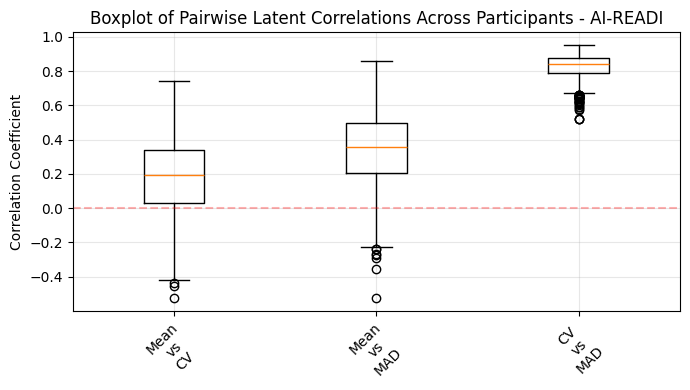

In [11]:
# Extract all pairwise correlations across patients
n_features = len(feature_names)
pair_correlations = []
pair_names = []

# Get all unique pairs of features
for i in range(n_features):
    for j in range(i+1, n_features):
        # Extract correlation for this pair across all patients
        corrs = aiready_latentcor[:, i, j]
        pair_correlations.append(corrs)
        pair_names.append(f'{feature_names[i]}\nvs\n{feature_names[j]}')

# Create boxplot with reduced box widths
plt.figure(figsize=(7, 4))
bp = plt.boxplot(pair_correlations, widths=0.3, tick_labels=pair_names)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title('Boxplot of Pairwise Latent Correlations Across Participants - AI-READI')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()